<a href="https://colab.research.google.com/github/AMeredith05/Modeling-magnetic-braking-of-Pleiades-stars/blob/main/Magnetic_braking_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Loads data tables, sorts/names columns,

In [72]:
colspecs_t2 = [
    (0, 9),    # EPIC
    (10, 28),  # Name
    (29, 37),  # RAdeg
    (38, 46),  # DEdeg
    (47, 70),  # Other
    (71, 76),  # Vmag
    (77, 82),  # Ksmag
    (83, 88),  # V-K
    (89, 96),  # Per1
    (97, 103), # Per2
    (104, 110),# Per3
    (111, 118),# Per4
    (119, 124),# Ampl
    (125, 128),# LC
    (129, 133),# memb
    (134, 139),# Per
    (140, 145) # vsini
]

names_t2 = [
    "EPIC","Name","RAdeg","DEdeg","Other","Vmag","Ksmag","VminusK",
    "Per1","Per2","Per3","Per4","Ampl","LC","memb","Per","vsini"
]

colspecs_t6 = [
    (0, 9),    # EPIC
    (10, 28),  # Name
    (29, 37),  # RAdeg
    (38, 46),  # DEdeg
    (47, 70),  # Other
    (71, 76),  # Mass
    (77, 82),  # Radius
    (83, 88),  # Teff
    (89, 96),  # Lum
    (97, 103), # Prot
    (104, 110),# e_Prot
    (111, 118) # Flag
]

names_t6 = [
    "EPIC","Name","RAdeg","DEdeg","Other","Mass","Radius","Teff",
    "Lum","Prot","e_Prot","Flag"
]



import pandas as pd
import requests
from io import StringIO

def load_rebull_table(url, colspecs, names, skiprows):
    txt = requests.get(url).text
    df = pd.read_fwf(
        StringIO(txt),
        colspecs=colspecs,
        names=names,
        skiprows=skiprows
    )
    return df

###Imputs URLs, prints tables after line 40

In [73]:
import pandas as pd
import requests
from io import StringIO

def load_rebull_table(url, colspecs, names, skiprows):
    txt = requests.get(url).text
    df = pd.read_fwf(
        StringIO(txt),
        colspecs=colspecs,
        names=names,
        skiprows=skiprows
    )
    return df

url_t2 = "https://content.cld.iop.org/journals/1538-3881/152/5/113/revision1/ajaa2e04t2_mrt.txt"
t2 = load_rebull_table(url_t2, colspecs_t2, names_t2, skiprows=40)


#url_t6 = "https://content.cld.iop.org/journals/1538-3881/152/5/113/revision1/ajaa2e04t6_mrt.txt"
#t6 = load_rebull_table(url_t6, colspecs_t6, names_t6, skiprows=40)

print("T2:", t2.head())
#print("T6:", t6.head())

T2:         EPIC                Name     RAdeg     DEdeg                    Other  \
0  210991540  033149.84+225024.8  52.95768  22.84023  UGCSJ033149.85+225024.4   
1  211016313  033207.85+231357.5  53.03274  23.23265                    DH017   
2  211029135  033237.80+232559.3  53.15753  23.43315  UGCSJ033237.82+232559.0   
3  211037397  033242.30+233400.4  53.17625  23.56679                    DH022   
4  210946764  033305.82+220803.2  53.27427  22.13423                  PELS004   

    Vmag  Ksmag  VminusK    Per1    Per2  Per3  Per4   Ampl   LC  memb   Per  \
0    NaN  12.75     5.10  0.5749     NaN   NaN   NaN  0.059  LC2  best  0.57   
1    NaN  12.25     5.05  0.3193     NaN   NaN   NaN  0.056  LC1  best   NaN   
2    NaN  13.06     5.76  0.2860     NaN   NaN   NaN  0.032  LC4  best   NaN   
3    NaN  12.54     5.58  0.4990  0.3167   NaN   NaN  0.023  LC1  best   NaN   
4  11.36   9.43     1.82  5.7660     NaN   NaN   NaN  0.011  LC4  best   NaN   

   vsini  
0    NaN  
1    N

In [74]:
t2["EPIC"] = t2["EPIC"].astype(str).str.strip()


###Merges/cleans datasets so only stars included in all 3 tables are considered

In [75]:
df = t2.copy()

# Keep only high-confidence members
df = df[df["memb"].isin(["best", "ok"])]

# Keep stars with measured rotation periods
df = df[df["Per1"].notna()]

# Convert numeric columns
df["Per1"] = pd.to_numeric(df["Per1"], errors="coerce")
df = df.dropna(subset=["Per1"])

periods_obs = df["Per1"].values
print(len(periods_obs))

759


###Spin-evolution Ordinary Differential Equation Assuming constant I

In [76]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

#Skumanich-type braking law
#Time unit: Myr (1,000,000 years)
#angular deceleration of a rotating object under a torque that depends on its angular speed
#K: torque strength, n: scaling exponent for spin down
def spin_down_ode(t, omega, K, n, I):
    return - (K / I) * omega**n

#moment of intertia
# cannot match moment of inertia for t2 stars from t6; IDs do not match
I_const = 1.0


#Estimated age of Pleiades is between 75-150 million years
age_cluster_Myr = 112.5
age_cluster_days = age_cluster_Myr * 1e6 * 365.25

#IVP evolves star to 112.5 Myr
def evolve_star(omega0, t_max_Myr, K, n, I):
    t_span = (0.0, t_max_Myr)
    t_eval = np.linspace(0.0, t_max_Myr, 500)
    sol = solve_ivp(spin_down_ode, t_span, [omega0],args=(K, n, I),t_eval=t_eval,rtol=1e-8, atol=1e-10)
    return t_eval, sol.y[0]

### Monte carlo initial conditions and population evolution

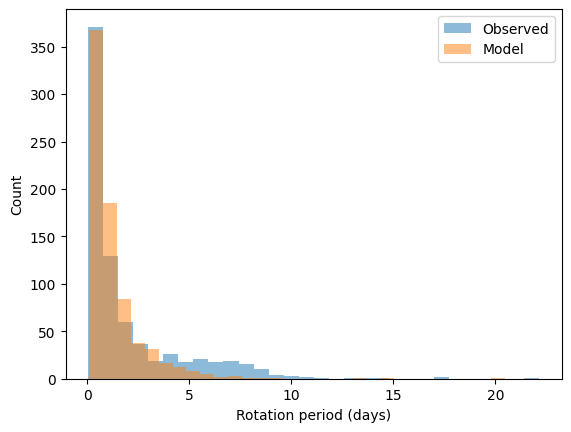

In [77]:
#previous attempts: mean_logP= #0.3, sigma_logP = 0.3; 1.0,0.5;
def sample_initial_periods(N, mean_logP= -0.3, sigma_logP=1.05):
    # 1.0, 0.5
    #og-normal of P in days
    P0 = np.random.lognormal(mean=mean_logP, sigma=sigma_logP, size=N)
    return P0
    #solution:

def evolve_population(N, age_Myr, K, n, I):
    P0 = sample_initial_periods(N)
    omega0 = 2 * np.pi / P0
    P_final = []

    for w0 in omega0:
        _, w_t = evolve_star(w0, age_Myr, K, n, I)
        P_final.append(2 * np.pi / w_t[-1])

    return np.array(P_final)

#comparing to observed periods
periods_obs = df["Per1"].astype(float).values  #unit: days

#model distribution
K_guess = 1e-6 #previos: 1e-3
n_guess = 3.0
N_model = len(periods_obs)
#P_model = evolve_population(N_model, age_cluster_days, K_guess, n_guess, I_const)
P_model = evolve_population(N_model, age_cluster_Myr, K_guess, n_guess, I_const)

import matplotlib.pyplot as plt


plt.hist(periods_obs, bins=30, alpha=0.5, label="Observed")
plt.hist(P_model, bins=30, alpha=0.5, label="Model")
plt.xlabel("Rotation period (days)")
plt.ylabel("Count")
plt.legend()
plt.show()

### Spin evolution assuming constant I

In [78]:
import numpy as np

def sample_initial_periods(N, mean_logP=np.log(2.0), sigma_logP=0.3):
    # log-normal in P (days), centered around ~2 days
    P0 = np.random.lognormal(mean=mean_logP, sigma=sigma_logP, size=N)
    P0 = np.clip(P0, 0.1, None)  # avoid absurdly small periods
    return P0

#picks one star for data
P0 = sample_initial_periods(1)[0]
omega0 = 2 * np.pi / P0

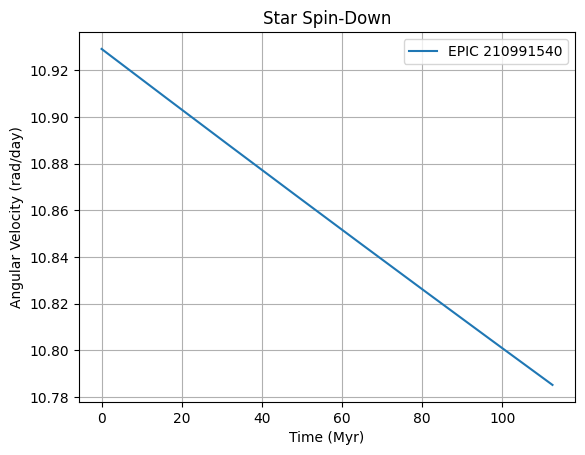

In [79]:
import matplotlib.pyplot as plt
import numpy as np

#Picks a star from T2 dataset
star = df.iloc[0]          # or df.loc[df["EPIC"] == some_id]
P_now = float(star["Per1"])  #unit: days

#Converts period to angular velocity
omega0 = 2 * np.pi / P_now   # rad/day

#Evolves the star
t_max_Myr = 112.5
K = 1e-6
n = 3
I =  1.0
t, omega = evolve_star(omega0, t_max_Myr, K, n, I)

plt.plot(t, omega, label=f"EPIC {int(star['EPIC'])}")
plt.xlabel("Time (Myr)")
plt.ylabel("Angular Velocity (rad/day)")
plt.title("Star Spin-Down")
plt.grid(True)
plt.legend()
plt.show()


##Reverse spin-evolution assuming constant I

In [80]:
import numpy as np
from scipy.integrate import solve_ivp

'''def spin_down_ode(t, omega, K, n, I):
    # dω/dt = - (K/I) ω^n
    return - (K / I) * omega**n'''

def evolve_star_backward(omega_now, t_now_Myr, t_start_Myr, K, n, I):
    """
    Integrate ω(t) backward from t_now to t_start.
    t_now_Myr > t_start_Myr
    """
    t_span = (t_now_Myr, t_start_Myr)  # backward in time
    t_eval = np.linspace(t_now_Myr, t_start_Myr, 500)

    sol = solve_ivp(
        spin_down_ode,
        t_span,
        [omega_now],
        args=(K, n, I),
        t_eval=t_eval,
        rtol=1e-8,
        atol=1e-10,
        max_step=0.5
    )

    if not sol.success or np.any(sol.y[0] <= 0):
        return None, None

    # Return times in increasing order, and ω(t) accordingly
    t_back = sol.t[::-1]
    omega_back = sol.y[0][::-1]
    return t_back, omega_back

In [81]:
# Example: pick 3 stars spanning the period range
df_use = df[df["Per1"].notna()].copy()
df_use = df_use.sort_values("Per1")

star_slow  = df_use.iloc[-1]   # longest period
star_mid   = df_use.iloc[len(df_use)//2]
star_fast  = df_use.iloc[0]    # shortest period

#stars = [star_fast, star_mid, star_slow]
stars = [star_mid]

age_cluster_Myr = 125.0
t_start_Myr = 5.0   # "initial" age to infer back to

K = 1e-5
n = 3.0
I =  1.0

In [82]:
results = []

for s in stars:
    P_now = float(s["Per1"])          # days
    omega_now = 2 * np.pi / P_now     # rad/day

    t_back, omega_back = evolve_star_backward(
        omega_now,
        age_cluster_Myr,
        t_start_Myr,
        K, n, I
    )

    if t_back is None:
        print("Backward integration failed for EPIC", s["EPIC"])
        continue

    # Initial angular velocity at t_start
    omega_init = omega_back[0]
    P_init = 2 * np.pi / omega_init   # days

    results.append({
        "EPIC": s["EPIC"],
        "P_now": P_now,
        "P_init": P_init
    })

results

[{'EPIC': '211039840',
  'P_now': 0.8002,
  'P_init': np.float64(0.7386283488666953)}]

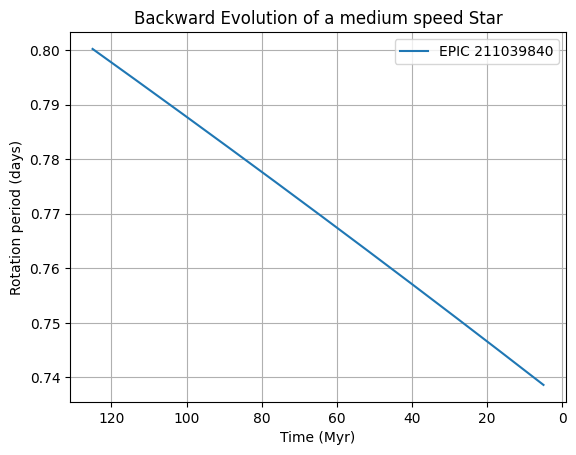

In [83]:
import matplotlib.pyplot as plt

for s in stars:
    P_now = float(s["Per1"])
    omega_now = 2 * np.pi / P_now

    t_back, omega_back = evolve_star_backward(
        omega_now,
        age_cluster_Myr,
        t_start_Myr,
        K, n, I
    )
    if t_back is None:
        continue

    P_back = 2 * np.pi / omega_back

    plt.plot(t_back, P_back, label=f"EPIC {s['EPIC']}")

plt.xlabel("Time (Myr)")
plt.ylabel("Rotation period (days)")
plt.gca().invert_xaxis()  # so time runs from early (left) to now (right)
plt.legend()
plt.title("Backward Evolution of a medium speed Star")
plt.grid(True)
plt.show()

##Using color (V-K) as a mass proxy

In [84]:
def mass_from_color(VK):
    # Clip to reasonable range
    VK = np.clip(VK, 1.0, 4.0)
    return 1.2 - 0.15 * (VK - 1.0)   # in solar masses

def radius_from_mass(M):
    return M**0.8   # in solar radii

def moment_of_inertia(M, R, k2=0.2):
    return k2 * M * R**2   # in solar units (arbitrary scaling)

df["Mass_est"] = mass_from_color(df["VminusK"])
df["Radius_est"] = radius_from_mass(df["Mass_est"])
df["I_est"] = moment_of_inertia(df["Mass_est"], df["Radius_est"])
df[["EPIC", "VminusK", "Mass_est", "Radius_est", "I_est"]].head()

,EPIC,VminusK,Mass_est,Radius_est,I_est
0,210991540,5.10,0.750,0.794418,0.094665
1,211016313,5.05,0.750,0.794418,0.094665
2,211029135,5.76,0.750,0.794418,0.094665
3,211037397,5.58,0.750,0.794418,0.094665
4,210946764,1.82,1.077,1.061140,0.242544


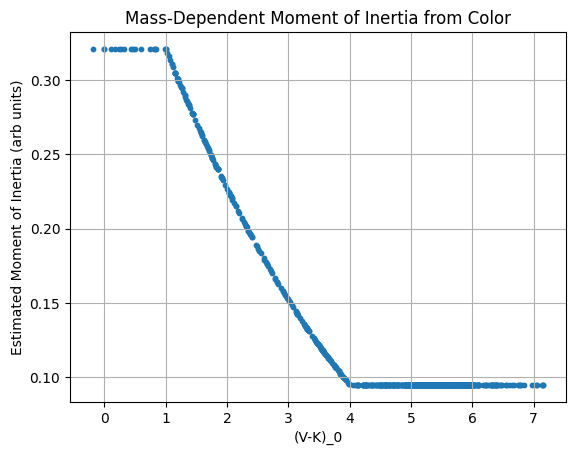

In [85]:
for _, row in df.iterrows():
    I = row["I_est"]
    P_now = row["Per1"]
    omega0 = 2 * np.pi / P_now

    t, omega = evolve_star(omega0, t_max_Myr, K, n, I)

plt.scatter(df["VminusK"], df["I_est"], s=10)
plt.xlabel("(V-K)_0")
plt.ylabel("Estimated Moment of Inertia (arb units)")
plt.title("Mass-Dependent Moment of Inertia from Color")
plt.grid(True)
plt.show()

### Spin-evolution with time-dependent moment of inertia

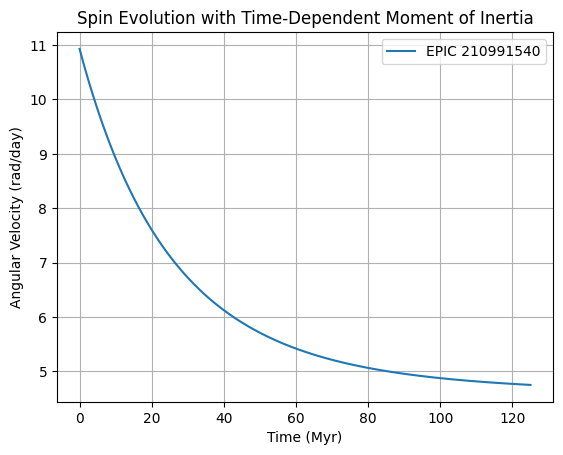

In [86]:
def radius_time_evolution(M, t_Myr):
    R_zams = M**0.8
    R_early = 1.5*R_zams
    tau = 30.0
    return R_zams + (R_early - R_zams) * np.exp(-t_Myr/tau)

def I_of_t(M, t):
    R = radius_time_evolution(M, t)
    k2 = 0.2
    return k2 * M * R**2

def spin_down_ode_time_dependent(t, omega, K, n, M):
    I_t = I_of_t(M, t)
    dt = 1e-3
    I_plus = I_of_t(M, t + dt)
    dIdt = (I_plus - I_t) / dt
    return -(K / I_t) * omega**n + omega * (dIdt / I_t)

def evolve_star_time_dependent(omega0, t_max_Myr, K, n, M):
    t_span = (0.0, t_max_Myr)
    t_eval = np.linspace(0.0, t_max_Myr, 500)

    sol = solve_ivp(
        spin_down_ode_time_dependent,
        t_span,
        [omega0],
        args=(K, n, M),
        t_eval=t_eval,
        rtol=1e-8,
        atol=1e-10
    )
    return sol.t, sol.y[0]

star = df.iloc[0]
P_now = float(star["Per1"])
omega0 = 2 * np.pi / P_now
M = mass_from_color(star["VminusK"])

t_back, omega = evolve_star_time_dependent(omega0, 125, K=1e-6, n=3, M=M)

plt.plot(t_back, omega, label=f"EPIC {int(star['EPIC'])}")
plt.xlabel("Time (Myr)")
plt.ylabel("Angular Velocity (rad/day)")
plt.title("Spin Evolution with Time-Dependent Moment of Inertia")
plt.grid(True)
plt.legend()
plt.show()

### Reverse spin evolution with time-dependent moment of inertia

In [87]:
def evolve_star_backward_time_dependent(omega_now, t_now_Myr, t_start_Myr, K, n, M):
    """
    Integrate ω(t) backward from t_now → t_start using time-dependent I(t).
    """
    t_span = (t_now_Myr, t_start_Myr)  # backward direction
    t_eval = np.linspace(t_now_Myr, t_start_Myr, 500)

    sol = solve_ivp(
        spin_down_ode_time_dependent,
        t_span,
        [omega_now],
        args=(K, n, M),
        t_eval=t_eval,
        rtol=1e-8,
        atol=1e-10,
        max_step=0.5
    )

    if not sol.success or np.any(sol.y[0] <= 0):
        return None, None

    # reverse arrays so time increases left to right
    t_back = sol.t[::-1]
    omega_back = sol.y[0][::-1]
    return t_back, omega_back

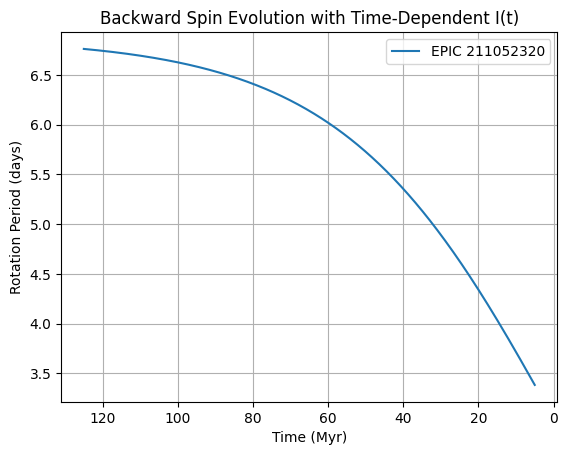

In [92]:
#picks a star
#star = df.iloc[0]   # or df.loc[df["EPIC"] == some_id]
star = df.iloc[-1]

P_now = float(star["Per1"])
omega_now = 2 * np.pi / P_now
M = mass_from_color(star["VminusK"])

t_now = 125.0
t_start = 5.0

K = 1e-6
n = 3

t_back, omega_back = evolve_star_backward_time_dependent(
    omega_now, t_now, t_start, K, n, M
)


P_back = 2 * np.pi / omega_back

plt.plot(t_back, P_back, label=f"EPIC {int(star['EPIC'])}")
plt.xlabel("Time (Myr)")
plt.ylabel("Rotation Period (days)")
plt.gca().invert_xaxis()  #time runs from early to now
plt.title("Backward Spin Evolution with Time-Dependent I(t)")
plt.grid(True)
plt.legend()
plt.show()

###Animation: rotational period distribution of a cluster over time (no new stellar formations)

All animation code blocks are designed to be ran within Google Colab; to run these animations in another interface, changes to the code may be required

In [ ]:
def evolve_population(P0_array, t_grid, K, n, M_array):
    N = len(P0_array)
    periods = np.zeros((len(t_grid), N))

    for i in range(N):
        omega0 = 2 * np.pi / P0_array[i]
        M = M_array[i]

        #evolves star
        sol = solve_ivp(
            spin_down_ode_time_dependent,
            (t_grid[0], t_grid[-1]),
            [omega0],
            args=(K, n, M),
            t_eval=t_grid,
            rtol=1e-8,
            atol=1e-10
        )

        omega_t = sol.y[0]
        periods[:, i] = 2 * np.pi / omega_t

    return periods

In [ ]:
#Number of stars
Nstars = 300

#Initial rotation periods (days)
P0 = np.random.lognormal(mean=np.log(2.0), sigma=0.3, size=Nstars)

# Colors to masses
VK = np.random.uniform(1.0, 4.0, size=Nstars)
M_array = mass_from_color(VK)

#Time grid (in Myr)
t_grid = np.linspace(5.0, 125.0, 80)

#Model parameters
K = 1e-6
n = 3

#Evolve the population
periods_t = evolve_population(P0, t_grid, K, n, M_array)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter, FFMpegWriter
from IPython.display import HTML
import numpy as np

fig, ax = plt.subplots(figsize=(7,5))
bins = np.linspace(0, 15, 40)

#Initial histogram
counts, bin_edges = np.histogram(periods_t[0], bins=bins)
bars = ax.bar(bin_edges[:-1], counts, width=np.diff(bin_edges), align='edge', color='skyblue')

#Fix axes
ax.set_xlim(0, 15)

all_counts = [np.histogram(periods_t[i], bins=bins)[0] for i in range(len(t_grid))]
ymax = max(c.max() for c in all_counts) * 1.2
ax.set_ylim(0, ymax)

ax.set_xlabel("Rotation Period (days)")
ax.set_ylabel("Number of Stars")
title = ax.set_title(f"t = {t_grid[0]:.1f} Myr")

def update(frame):
    counts, _ = np.histogram(periods_t[frame], bins=bins)

    for bar, h in zip(bars, counts):
        bar.set_height(h)

    title.set_text(f"t = {t_grid[frame]:.1f} Myr")

    return bars

anim = FuncAnimation(fig, update, frames=len(t_grid), interval=120, blit=True)
HTML(anim.to_jshtml())

###Animation: Radius contraction over time

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter, FFMpegWriter
from IPython.display import HTML, display
import numpy as np
import os

anim = FuncAnimation(
    fig,
    update,
    frames=len(t_grid),
    init_func=init,
    interval=120,
    blit=False
)

#displays Animation
try:
    display(HTML(anim.to_jshtml()))
    print("Animation displayed inline (JSHTML).")
except NameError:
    print("HTML and display not available (likely not in Colab/Jupyter).")
except Exception as e:
    print(f"Could not display animation inline: {e}")


###Animation: Angular velo. vs time for multiple masses

In [ ]:
masses = [0.3, 0.5, 0.8, 1.0]   # solar masses in range of K-M dwarfs

P0 = 2.0  # days
omega0 = 2 * np.pi / P0

import matplotlib.pyplot as plt

t_max = 125.0
K = 1e-6
n = 3

plt.figure(figsize=(8,6))

for M in masses:
    t, omega = evolve_star_time_dependent(omega0, t_max, K, n, M)
    plt.plot(t, omega, label=f"M = {M:.1f} M☉")

plt.xlabel("Time (Myr)")
plt.ylabel("Angular Velocity (rad/day)")
plt.title("Angular Velocity vs Time for Multiple Stellar Masses")
plt.grid(True)
plt.legend()
plt.show()